<a href="https://colab.research.google.com/github/eesabatan/coursework-2/blob/main/The_final_PyCaret_cw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-zgto2u8l
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-zgto2u8l
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# numpy and pandas used for data manipulation
import numpy as np
import pandas as pd
# matplotlib used to visually represent data
import matplotlib.pyplot as plt
# yfinance used to import historical data
import yfinance as yfin

In [ ]:
#set ticker
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)

#Import data
data = ticker.history(period='5y')

<Axes: xlabel='Date', ylabel='Amazon'>

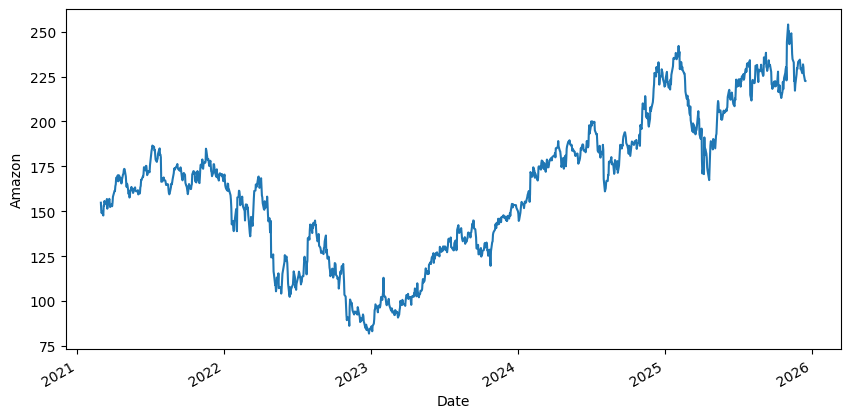

In [ ]:
plt.ylabel("Amazon")

data['Close'].plot(figsize=(10,5))

In [ ]:
# Setting the training set to 80% of the data
X = data_rfr.drop('Close', axis=1)
y = data_rfr['Close']
training = 0.7
t = int(training*len(X))

# Training dataset
data_train_X = X[:t]
data_train_y = y[:t]

# Testing dataset
data_test_X = X[t:]
data_test_y = y[t:]

In [ ]:
from pycaret.regression import *
s = setup(
    data=data[['SMA_20','SMA_50','Close']],
    target='Close',
    session_id=123,
    numeric_features=['SMA_20', 'SMA_50'],
    fold_strategy='timeseries', # Ensures temporal integrity
    data_split_shuffle=False,     # Prevents random shuffling
    n_jobs=-1
)

,Description,Value
0,Session id,123
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1206, 3)"
4,Transformed data shape,"(1206, 3)"
5,Transformed train set shape,"(844, 3)"
6,Transformed test set shape,"(362, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


In [ ]:
# Create a Linear Regression model
lr = create_model('lr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,6.8392,69.1039,8.3129,-0.2234,0.0481,0.0405
1,6.0228,69.4331,8.3327,0.3986,0.0525,0.0380
2,13.2437,269.8839,16.4281,0.2688,0.1220,0.1023
3,11.9875,211.3401,14.5375,-0.4445,0.1221,0.0952
4,7.8004,88.8793,9.4276,0.5199,0.0904,0.0793
5,5.3812,41.5844,6.4486,-0.5468,0.0668,0.0545
6,3.8550,22.3178,4.7242,0.7931,0.0390,0.0313
7,5.2023,40.8974,6.3951,0.1273,0.0471,0.0383
8,3.9754,28.9527,5.3808,0.7751,0.0329,0.0242


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

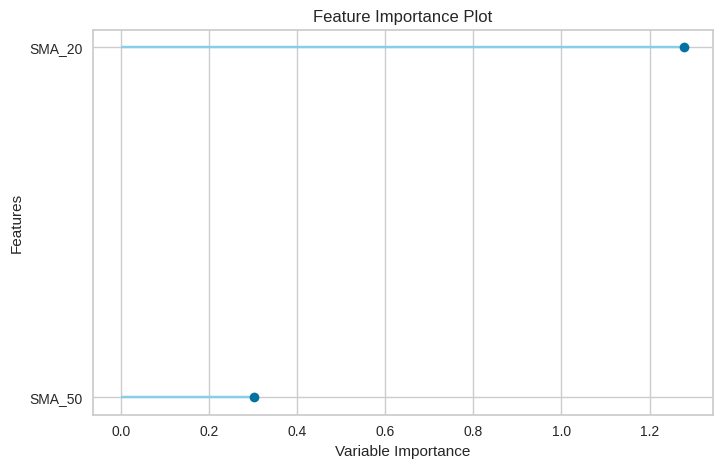

In [ ]:
from pycaret.regression import plot_model
plot_model(lr, plot='feature')

In [ ]:
from pycaret.regression import predict_model
predict_model(lr);

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,7.7475,95.0461,9.7492,0.7796,0.0473,0.0375


In [ ]:
unseen_predictions = predict_model(lr)
unseen_predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,7.7475,95.0461,9.7492,0.7796,0.0473,0.0375


,SMA_20,SMA_50,Close,prediction_label
Date,,,,
2024-07-10 00:00:00-04:00,191.037994,186.329605,199.789993,191.625763
2024-07-11 00:00:00-04:00,191.674500,186.733002,195.050003,192.317886
2024-07-12 00:00:00-04:00,192.065506,187.014801,194.490005,192.732788
2024-07-15 00:00:00-04:00,192.445496,187.404602,192.720001,193.100922
2024-07-16 00:00:00-04:00,192.889999,187.679001,193.020004,193.586487
...,...,...,...,...
2025-12-10 00:00:00-05:00,230.698502,228.647400,231.779999,229.554276
2025-12-11 00:00:00-05:00,229.832504,228.891602,230.279999,228.372635
2025-12-12 00:00:00-05:00,229.136505,229.084595,226.190002,227.423950


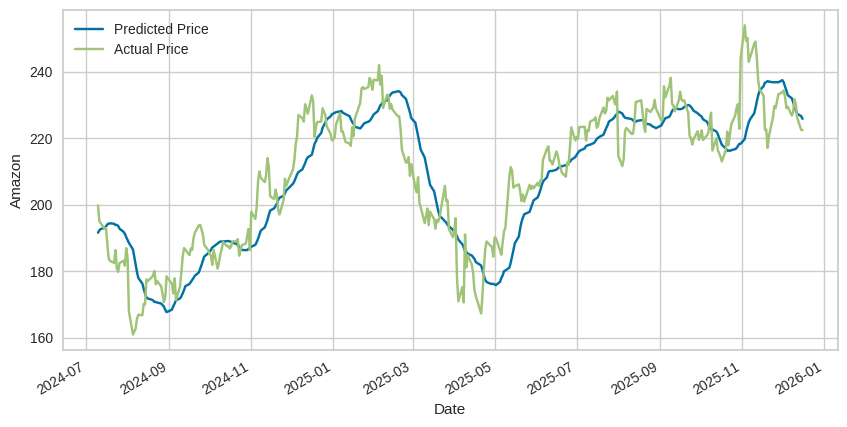

In [ ]:
predicted_price = pd.DataFrame(unseen_predictions,index=unseen_predictions.index,columns = ['prediction_label'])
predicted_price.plot(figsize=(10,5))
unseen_predictions['Close'].plot()
plt.legend(['Predicted Price','Actual Price'])
plt.ylabel("Amazon")
plt.show()

In [ ]:
from pycaret.regression import evaluate_model
evaluate_model(lr)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# simple moving average (SMA)
data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()
data['SMA_50'] = data['Close'].shift(1).rolling(window=50).mean()

# exponential moving averages (EMA)
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

#calculate realtive strength index (RSI)
delta = data['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2020-12-16 00:00:00-05:00,158.800507,162.350006,158.184006,162.048004,88552000,0.0,0.0,NaN,NaN,162.048004,NaN
2020-12-17 00:00:00-05:00,162.500000,163.175507,161.050003,161.804001,69486000,0.0,0.0,NaN,NaN,162.024766,NaN
2020-12-18 00:00:00-05:00,162.199493,162.470993,158.580002,160.082504,119914000,0.0,0.0,NaN,NaN,161.839788,NaN
2020-12-21 00:00:00-05:00,160.000504,161.348495,158.300003,160.309006,76736000,0.0,0.0,NaN,NaN,161.694000,NaN
2020-12-22 00:00:00-05:00,160.141998,161.100006,159.003998,160.326004,47388000,0.0,0.0,NaN,NaN,161.563714,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 00:00:00-05:00,228.809998,232.419998,228.460007,231.779999,38790700,0.0,0.0,230.698501,228.647401,230.592803,62.247373
2025-12-11 00:00:00-05:00,230.710007,232.110001,228.690002,230.279999,28249600,0.0,0.0,229.832500,228.891600,230.563013,69.872968
2025-12-12 00:00:00-05:00,229.869995,230.080002,225.119995,226.190002,35639100,0.0,0.0,229.136501,229.084600,230.146535,58.184530


In [ ]:
data = data.dropna()
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-03-02 00:00:00-05:00,157.173492,158.175995,154.356003,154.726501,51916000,0.0,0.0,162.899100,161.558651,160.165631,31.396405
2021-03-03 00:00:00-05:00,154.059006,155.389008,149.750000,150.250000,79774000,0.0,0.0,162.278226,161.412220,159.221285,27.890335
2021-03-04 00:00:00-05:00,150.600006,152.906494,147.271500,148.878494,109632000,0.0,0.0,161.340726,161.181140,158.236258,27.760406
2021-03-05 00:00:00-05:00,150.250000,150.449997,144.050003,150.022995,107772000,0.0,0.0,160.503326,160.957060,157.454042,28.576522
2021-03-08 00:00:00-05:00,150.750000,153.229507,147.565506,147.597504,83700000,0.0,0.0,159.676975,160.751340,156.515324,26.922655
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 00:00:00-05:00,228.809998,232.419998,228.460007,231.779999,38790700,0.0,0.0,230.698501,228.647401,230.592803,62.247373
2025-12-11 00:00:00-05:00,230.710007,232.110001,228.690002,230.279999,28249600,0.0,0.0,229.832500,228.891600,230.563013,69.872968
2025-12-12 00:00:00-05:00,229.869995,230.080002,225.119995,226.190002,35639100,0.0,0.0,229.136501,229.084600,230.146535,58.184530


In [ ]:
#random forest features
data_rfr = data[['SMA_20', 'EMA_20', 'SMA_50', 'RSI', 'Close']]


In [ ]:
data.head(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-03-02 00:00:00-05:00,157.173492,158.175995,154.356003,154.726501,51916000,0.0,0.0,162.899100,161.558651,160.165631,31.396405
2021-03-03 00:00:00-05:00,154.059006,155.389008,149.750000,150.250000,79774000,0.0,0.0,162.278226,161.412220,159.221285,27.890335
2021-03-04 00:00:00-05:00,150.600006,152.906494,147.271500,148.878494,109632000,0.0,0.0,161.340726,161.181140,158.236258,27.760406
2021-03-05 00:00:00-05:00,150.250000,150.449997,144.050003,150.022995,107772000,0.0,0.0,160.503326,160.957060,157.454042,28.576522
2021-03-08 00:00:00-05:00,150.750000,153.229507,147.565506,147.597504,83700000,0.0,0.0,159.676975,160.751340,156.515324,26.922655
2021-03-09 00:00:00-05:00,150.899506,154.548004,150.257507,153.142502,80600000,0.0,0.0,158.676476,160.496770,156.194103,33.787576
2021-03-10 00:00:00-05:00,154.922501,155.822998,151.502502,152.882004,60250000,0.0,0.0,158.026250,160.374350,155.878665,31.806641
2021-03-11 00:00:00-05:00,155.200500,156.589005,154.146500,155.679504,55528000,0.0,0.0,157.407851,160.259300,155.859697,40.550710
2021-03-12 00:00:00-05:00,153.750000,154.949005,152.274994,154.474503,48438000,0.0,0.0,156.975376,160.088930,155.727774,43.252839


In [ ]:
from pycaret.regression import setup

# Setup PyCaret environment
reg = setup(data=data_rfr, target='Close', session_id=42, train_size=0.7, fold_shuffle=True)

,Description,Value
0,Session id,42
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1206, 5)"
4,Transformed data shape,"(1206, 5)"
5,Transformed train set shape,"(844, 5)"
6,Transformed test set shape,"(362, 5)"
7,Numeric features,4
8,Preprocess,True
9,Imputation type,simple


In [ ]:
from pycaret.regression import create_model
rf_model = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.3609,12.2844,3.5049,0.9929,0.0215,0.0145
1,2.5348,11.1590,3.3405,0.9935,0.0206,0.0161
2,2.0285,7.7422,2.7825,0.9942,0.0179,0.0133
3,2.4637,12.8003,3.5777,0.9924,0.0232,0.0157
4,2.5161,12.7949,3.5770,0.9917,0.0271,0.0170
5,2.3789,11.0370,3.3222,0.9937,0.0190,0.0142
6,2.6299,12.4570,3.5294,0.9934,0.0233,0.0169
7,2.5315,13.1790,3.6303,0.9904,0.0223,0.0157
8,2.3511,8.6628,2.9433,0.9942,0.0207,0.0154


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

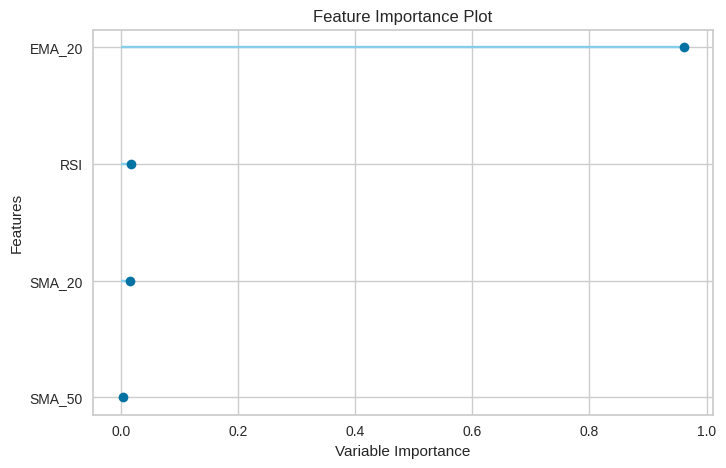

In [ ]:
from pycaret.regression import plot_model
plot_model(rf_model, plot='feature')

In [ ]:
from pycaret.regression import predict_model
predict_model(rf_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.4423,12.4990,3.5354,0.9925,0.0276,0.0171


,SMA_20,EMA_20,SMA_50,RSI,Close,prediction_label
Date,,,,,,
2021-07-26 00:00:00-04:00,179.464355,179.612228,170.934036,53.037632,184.990997,181.404431
2022-03-11 00:00:00-05:00,149.968048,147.815643,153.847397,42.693134,145.524506,147.080282
2024-04-03 00:00:00-04:00,177.115494,177.861298,171.563599,66.349922,182.410004,181.078556
2021-08-05 00:00:00-04:00,179.180756,175.116272,173.055923,34.209003,168.799500,168.823938
2023-09-28 00:00:00-04:00,136.438995,133.492615,134.955795,31.732817,125.980003,127.306602
...,...,...,...,...,...,...
2023-12-01 00:00:00-05:00,143.780502,143.348862,134.590393,59.088520,147.029999,146.398505
2024-04-18 00:00:00-04:00,182.136993,181.749634,176.889404,47.571182,179.220001,180.947059
2024-02-28 00:00:00-05:00,169.217499,169.156769,159.455399,54.854198,173.160004,172.945317


In [ ]:
unseenrf_predictions = predict_model(rf_model)
unseenrf_predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.4423,12.4990,3.5354,0.9925,0.0276,0.0171


,SMA_20,EMA_20,SMA_50,RSI,Close,prediction_label
Date,,,,,,
2021-07-26 00:00:00-04:00,179.464355,179.612228,170.934036,53.037632,184.990997,181.404431
2022-03-11 00:00:00-05:00,149.968048,147.815643,153.847397,42.693134,145.524506,147.080282
2024-04-03 00:00:00-04:00,177.115494,177.861298,171.563599,66.349922,182.410004,181.078556
2021-08-05 00:00:00-04:00,179.180756,175.116272,173.055923,34.209003,168.799500,168.823938
2023-09-28 00:00:00-04:00,136.438995,133.492615,134.955795,31.732817,125.980003,127.306602
...,...,...,...,...,...,...
2023-12-01 00:00:00-05:00,143.780502,143.348862,134.590393,59.088520,147.029999,146.398505
2024-04-18 00:00:00-04:00,182.136993,181.749634,176.889404,47.571182,179.220001,180.947059
2024-02-28 00:00:00-05:00,169.217499,169.156769,159.455399,54.854198,173.160004,172.945317


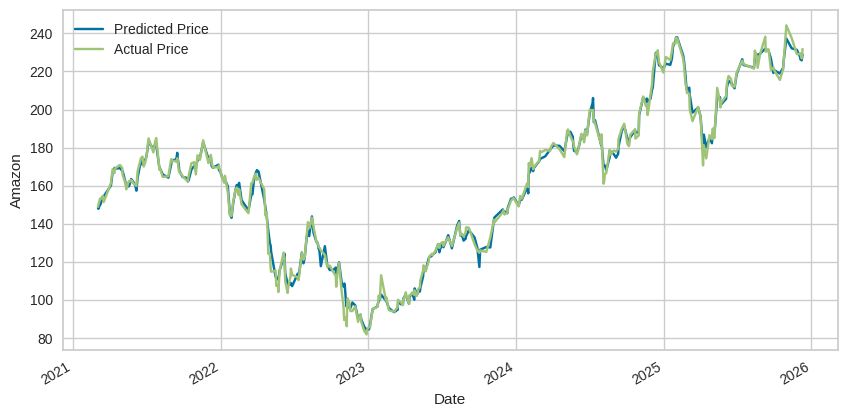

In [ ]:
predictedrf_price = pd.DataFrame(unseenrf_predictions,index=unseenrf_predictions.index,columns = ['prediction_label'])
predictedrf_price.plot(figsize=(10,5))
unseenrf_predictions['Close'].plot()
plt.legend(['Predicted Price','Actual Price'])
plt.ylabel("Amazon")
plt.show()

In [ ]:
from pycaret.regression import evaluate_model
evaluate_model(rf_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE for Linear Regression
rmse_lr = np.sqrt(mean_squared_error(
    unseen_predictions['Close'],
    unseen_predictions['prediction_label']
))

# RMSE for Random Forest
rmse_rf = np.sqrt(mean_squared_error(
    unseenrf_predictions['Close'],
    unseenrf_predictions['prediction_label']
))

print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")



Linear Regression RMSE: 9.75
Random Forest RMSE: 3.54
